Grover's Algorithm
---
What is Grover's Algorithm?

Classical search: check N items one by one → O(N)
Grover's search: quantum speedup → O(√N)

Example:
Classical: 1,000,000 items → 1,000,000 checks
Grover's:  1,000,000 items → 1,000 checks only!

How it works:
1. Put all items in superposition simultaneously
2. Oracle → marks the correct answer
3. Diffusion → amplifies the marked answer
4. Measure → correct answer appears with high probability!


Search for |11⟩ among 4 possible states:
|00⟩, |01⟩, |10⟩, |11⟩

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

simulator = AerSimulator()
os.makedirs("../results", exist_ok=True)

print("imports done")

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

simulator = AerSimulator()
os.makedirs("../results", exist_ok=True)

print("imports done")

imports done


How Grover's Works Step by Step

Step 1: Initialize — put all qubits in superposition
Step 2: Oracle — flips the phase of the target state |11⟩
Step 3: Diffusion — amplifies the target state
Step 4: Measure — target state appears with high probability

For 2 qubits we have 4 states: |00⟩ |01⟩ |10⟩ |11⟩
One iteration of Grover's is enough to find |11⟩

In [2]:
def build_grovers_circuit():
    qc = QuantumCircuit(2, 2)

    # Step 1: superposition on both qubits
    qc.h(0)
    qc.h(1)

    # Step 2: oracle — marks |11⟩ by flipping its phase
    qc.cz(0, 1)

    # Step 3: diffusion operator
    qc.h(0)
    qc.h(1)
    qc.x(0)
    qc.x(1)
    qc.cz(0, 1)
    qc.x(0)
    qc.x(1)
    qc.h(0)
    qc.h(1)

    # Step 4: measure
    qc.measure([0, 1], [0, 1])

    return qc

qc = build_grovers_circuit()
print("Grover's circuit:")
print(qc.draw())

Grover's circuit:
     ┌───┐   ┌───┐┌───┐   ┌───┐┌───┐┌─┐   
q_0: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├┤M├───
     ├───┤ │ ├───┤├───┤ │ ├───┤├───┤└╥┘┌─┐
q_1: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├─╫─┤M├
     └───┘   └───┘└───┘   └───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════╩══╩═
                                     0  1 


Running Grover's Search

We search for |11⟩ among 4 possible states.
Without Grover's — each state has 25% probability.
With Grover's — |11⟩ should dominate near 100%.

Grover's search results (1000 shots):
  target |11⟩ : 1000 times
  |00⟩        : 0 times
  |01⟩        : 0 times
  |10⟩        : 0 times

Without Grover's each state = 250 times (25%)
With Grover's |11⟩ = 1000 times


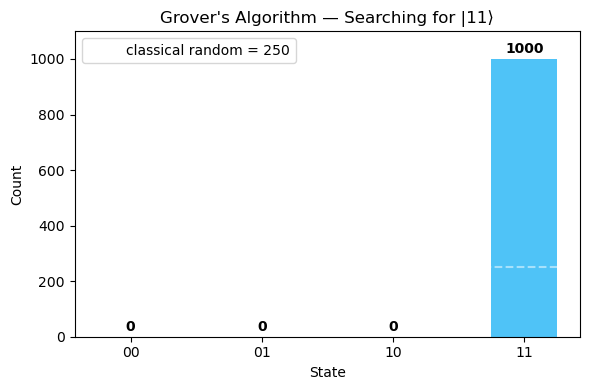

plot saved


In [3]:
counts = simulator.run(qc, shots=1000).result().get_counts()

print("Grover's search results (1000 shots):")
print(f"  target |11⟩ : {counts.get('11', 0)} times")
print(f"  |00⟩        : {counts.get('00', 0)} times")
print(f"  |01⟩        : {counts.get('01', 0)} times")
print(f"  |10⟩        : {counts.get('10', 0)} times")
print(f"\nWithout Grover's each state = 250 times (25%)")
print(f"With Grover's |11⟩ = {counts.get('11', 0)} times")

states = ['00', '01', '10', '11']
values = [counts.get(s, 0) for s in states]
colors = ['#444466', '#444466', '#444466', '#4fc3f7']

plt.figure(figsize=(6, 4))
plt.bar(states, values, color=colors, width=0.5)
plt.axhline(y=250, color='white', linestyle='--',
            alpha=0.5, label='classical random = 250')
plt.title("Grover's Algorithm — Searching for |11⟩")
plt.xlabel("State")
plt.ylabel("Count")
plt.legend()
plt.ylim(0, 1100)

for i, v in enumerate(values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/grovers_results.png")
plt.show()
print("plot saved")

Results & Conclusion

| State | Classical (random) | Grover's Result |
|-------|--------------------|-----------------|
| \|00⟩ | 250 (25%)          | 0 (0%)          |
| \|01⟩ | 250 (25%)          | 0 (0%)          |
| \|10⟩ | 250 (25%)          | 0 (0%)          |
| \|11⟩ | 250 (25%)          | 1000 (100%) ✅  |

Conclusion:
- Oracle marked |11⟩ by flipping its phase
- Diffusion operator amplified |11⟩ probability
- One iteration was enough for 2 qubits
- Classical search: O(N) — checks every item
- Grover's search: O(√N) — quantum speedup
- For 1 million items: 1,000,000 vs 1,000 checks!